C:\Users\owner\anaconda3\envs\rnaseq_correlations\lib\site-packages\scanpy\preprocessing\_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number
C:\Users\owner\anaconda3\envs\rnaseq_correlations\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\owner\anaconda3\envs\rnaseq_correlations\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


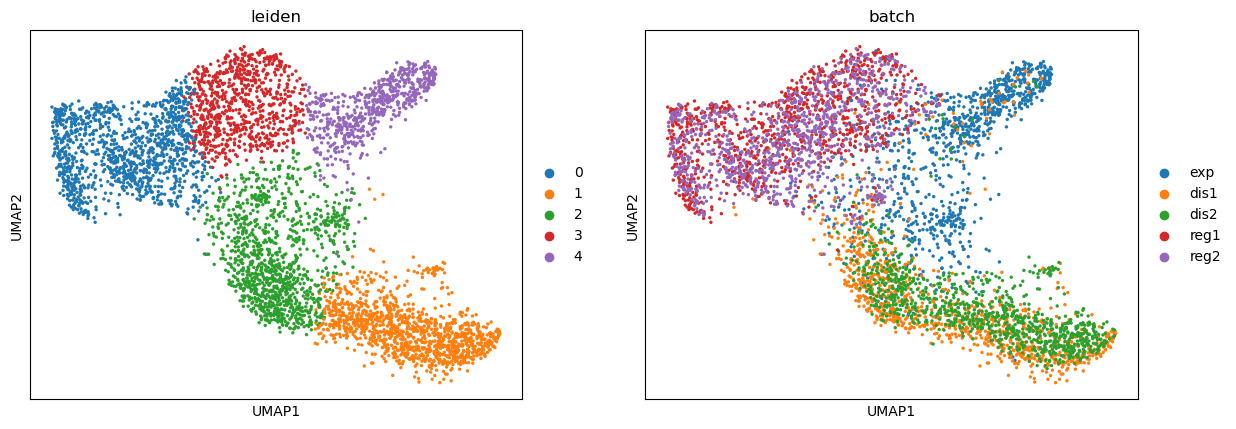

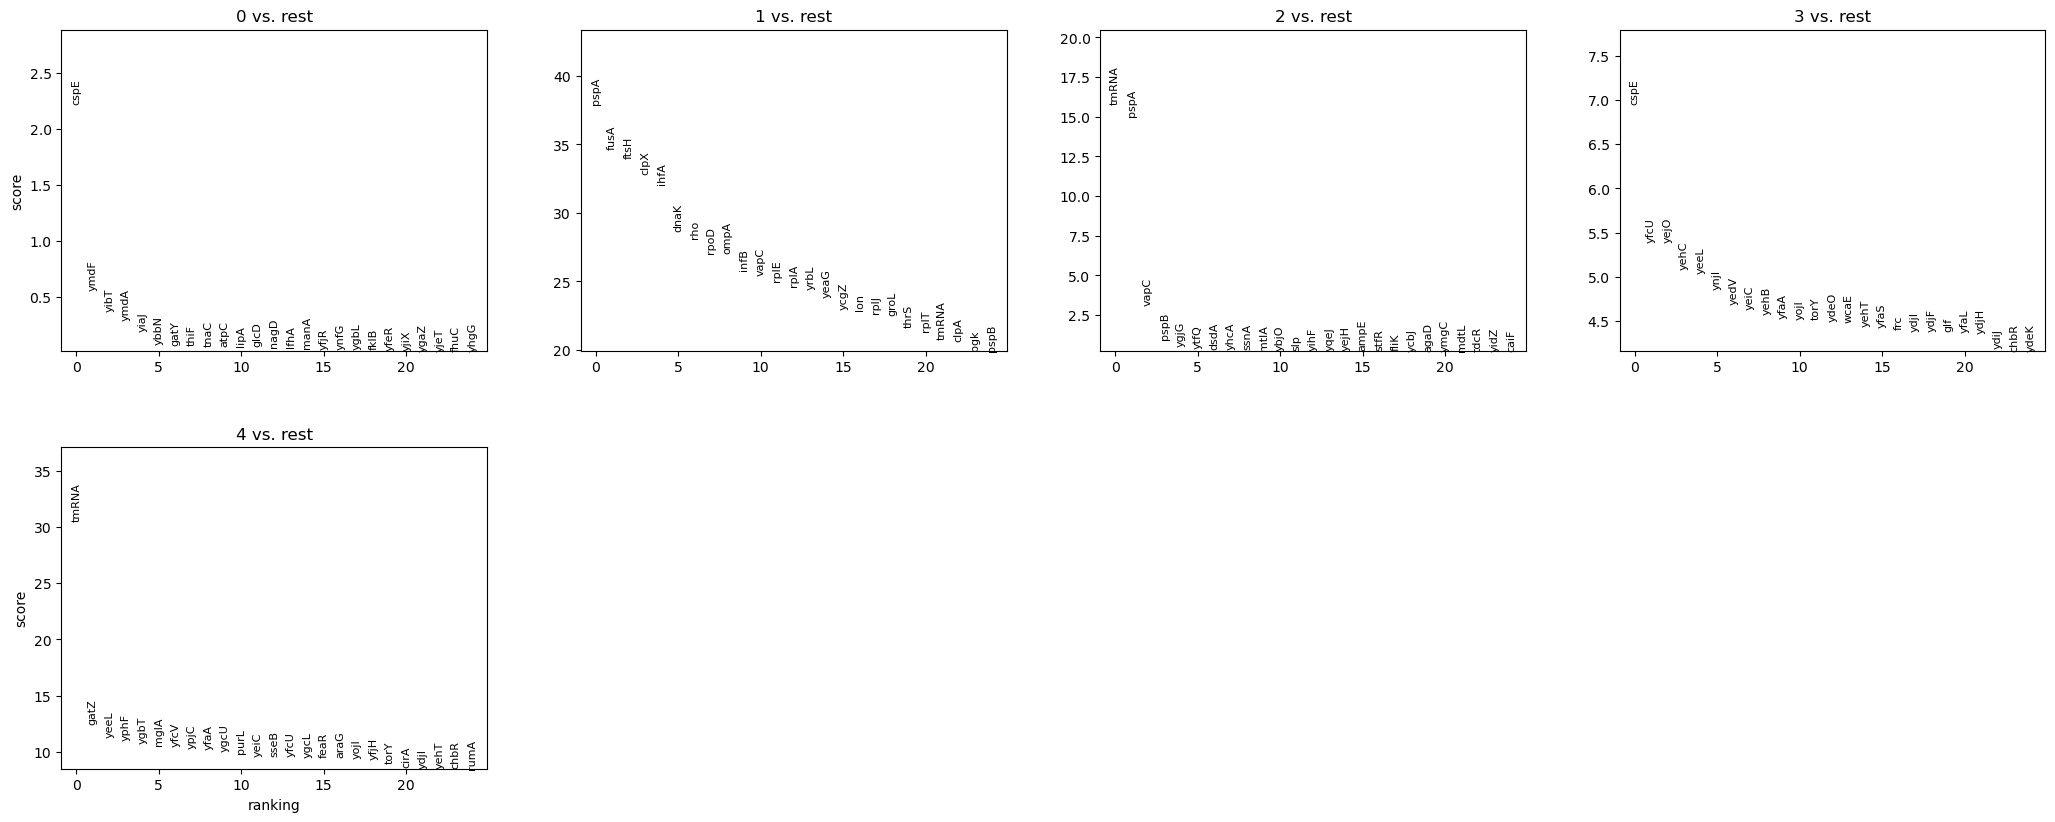

In [1]:
# concatenated matrix UMAP and marker gene analysis
import scanpy as sc
import os
import numpy as np
# concatenated matrix
dir = os.path.join(os.path.dirname(os.getcwd()), 'data_for_umap')
# exp
file_name = 'sample_2b_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
exp = sc.read_csv(path)
sc.pp.normalize_total(exp, target_sum=3802)  # Normalize
sc.pp.log1p(exp)  
# shx1
file_name = 'sample_13a_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
shx1 = sc.read_csv(path)
sc.pp.normalize_total(shx1, target_sum=3507)  # Normalize
sc.pp.log1p(shx1)  
# shx2
file_name = 'sample_15a_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
shx2 = sc.read_csv(path)
sc.pp.normalize_total(shx2, target_sum=3507)  # Normalize
sc.pp.log1p(shx2)  
# casp1
file_name = 'sample_13b_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
casp1 = sc.read_csv(path)
sc.pp.normalize_total(casp1, target_sum=46)  # Normalize
sc.pp.log1p(casp1)  
# casp2
file_name = 'sample_15b_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
casp2 = sc.read_csv(path)
sc.pp.normalize_total(casp2, target_sum=46)  # Normalize
sc.pp.log1p(casp2)

# Step 1: Load your data
adata = sc.concat(
    [exp, shx1,shx2,casp1, casp2],  # List of AnnData objects to concatenate
    label='batch',               # New column name in .obs that stores which sample each cell came from
    join='inner',  # How to join the data (outer = union of genes, inner = intersection)
    fill_value=0,  # Fill missing values with this
    keys=['exp', 'dis1','dis2','reg1','reg2'],  # Names for the batches
    index_unique='-'              # How to make cell names unique (Sample1-0, Sample1-1, etc.)
)  # Replace with your file path
# List of genes you want to remove
genes_to_remove = ['16s_mature', '16s_unprocessed','LELOBEKK','kanR','mCherry']  # Example genes
# Keep only genes not in the list
adata = adata[:, ~adata.var_names.isin(genes_to_remove)]
# Step 2: Basic preprocessing
#sc.pp.filter_cells(adata, min_counts=400)     # Optional: filter cells
sc.pp.filter_genes(adata, min_cells=3)    
# save raw counts layer
adata.layers["counts"] = adata.X.copy()
#sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize
#sc.pp.log1p(adata)                            # Log-transform
sc.pp.highly_variable_genes(adata, n_top_genes=2000,subset=True)  # Keep top 2000 HVGs
# Step 3: PCA
sc.pp.scale(adata)
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

# Step 4: Compute neighbors and run UMAP
sc.pp.neighbors(adata, n_neighbors=40, n_pcs=40)
sc.tl.umap(adata, min_dist=0.3, random_state=0)

# Step 5: Clustering
sc.tl.leiden(adata, resolution=.4)  # You can adjust resolution (higher = more clusters)


# Step 6: Plot UMAP
sc.pl.umap(adata, color=['leiden','batch'])
# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon', use_raw=False, layer='counts')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

# Optional: Save the results
#adata.write(r'C:\Users\owner\Documents\Projects\rnaseq_correlations\data\scanpy_shx_scaled_by_total_rna.h5ad')


In [70]:
# save UMAP coordinates to csv
import pandas as pd
#adata = sc.read_h5ad(os.path.join(os.path.dirname(os.getcwd()), 'scanpy', 'scanpy_exp2_combined.h5ad'))
# Extract umap coordinates from .obsm
umap_df = pd.DataFrame(
    adata.obsm["X_umap"],
    columns=["UMAP_1", "UMAP_2"],
    index=adata.obs_names  # keep cell names as index
)

# Add batch and cluster info from .obs
umap_df["batch"] = adata.obs["batch"].values
umap_df["cluster"] = adata.obs["leiden"].values  # or whatever clustering key you used

# Save to CSV
umap_df.to_csv(os.path.join(os.path.dirname(os.getcwd()), 'scanpy', 'umap_coordinates_shx_scaled.csv'))

C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


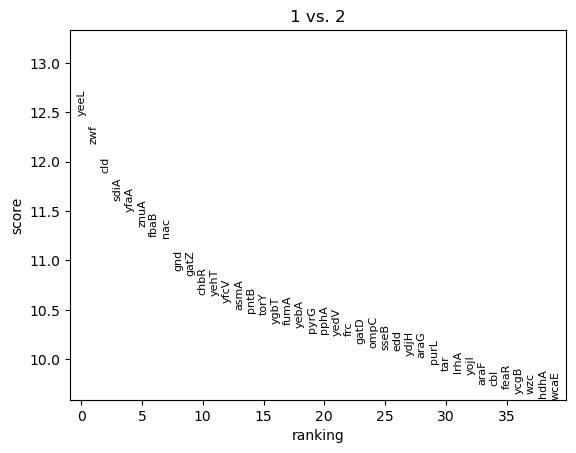

,gene,score,log2_fold_change,adjusted_pval
84,fliC,8.410899,NaN,5.190085e-16


In [105]:
# find marker genes between two clusters
# Choose your two clusters
clusters_of_interest = ['8', '2']  # Note: cluster names are strings

# Subset the data
adata_sub = adata[adata.obs['leiden'].isin(clusters_of_interest)].copy()
# Create a new label just for these two clusters
adata_sub.obs['sub_cluster'] = adata_sub.obs['leiden']
sc.tl.rank_genes_groups(
    adata_sub,
    groupby='sub_cluster', 
    groups=[clusters_of_interest[0]],  # Compare Cluster 0
    reference=clusters_of_interest[1],  # Against Cluster 1
    method='wilcoxon'
)
sc.pl.rank_genes_groups(adata_sub, n_genes=40, sharey=False)

import pandas as pd

# Extract DE results
genes = adata_sub.uns['rank_genes_groups']['names'][clusters_of_interest[0]]
scores = adata_sub.uns['rank_genes_groups']['scores'][clusters_of_interest[0]]
logfc = adata_sub.uns['rank_genes_groups']['logfoldchanges'][clusters_of_interest[0]]
pvals_adj = adata_sub.uns['rank_genes_groups']['pvals_adj'][clusters_of_interest[0]]

# Make a nice DataFrame
de_df = pd.DataFrame({
    'gene': genes,
    'score': scores,
    'log2_fold_change': logfc,
    'adjusted_pval': pvals_adj
})

de_df[de_df.gene=='fliC']

In [ ]:
import pandas as pd

# Choose the cluster you want
target_cluster = '1'  # Note: it's a string, not an integer!

# Extract the data
names = adata.uns['rank_genes_groups']['names'][target_cluster]
scores = adata.uns['rank_genes_groups']['scores'][target_cluster]
logfoldchanges = adata.uns['rank_genes_groups']['logfoldchanges'][target_cluster]
pvals_adj = adata.uns['rank_genes_groups']['pvals_adj'][target_cluster]

# Build a nice DataFrame
markers_df = pd.DataFrame({
    'gene': names,
    'score': scores,
    'log2_fold_change': logfoldchanges,
    'adjusted_pval': pvals_adj
})
# Print the table
markers_df

C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\preprocessing\_simple.py:282: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


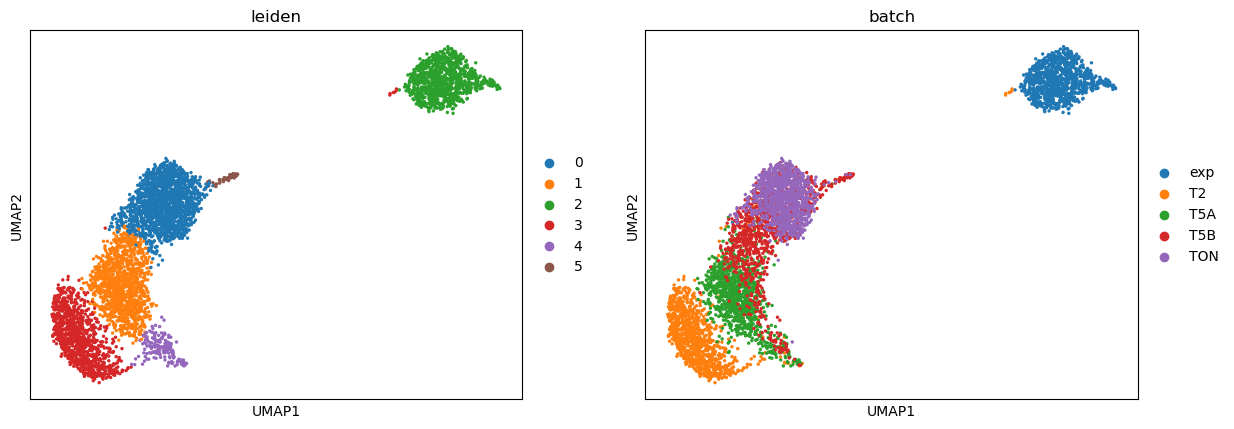

C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\owner\anaconda3\envs\scRNAseq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.l

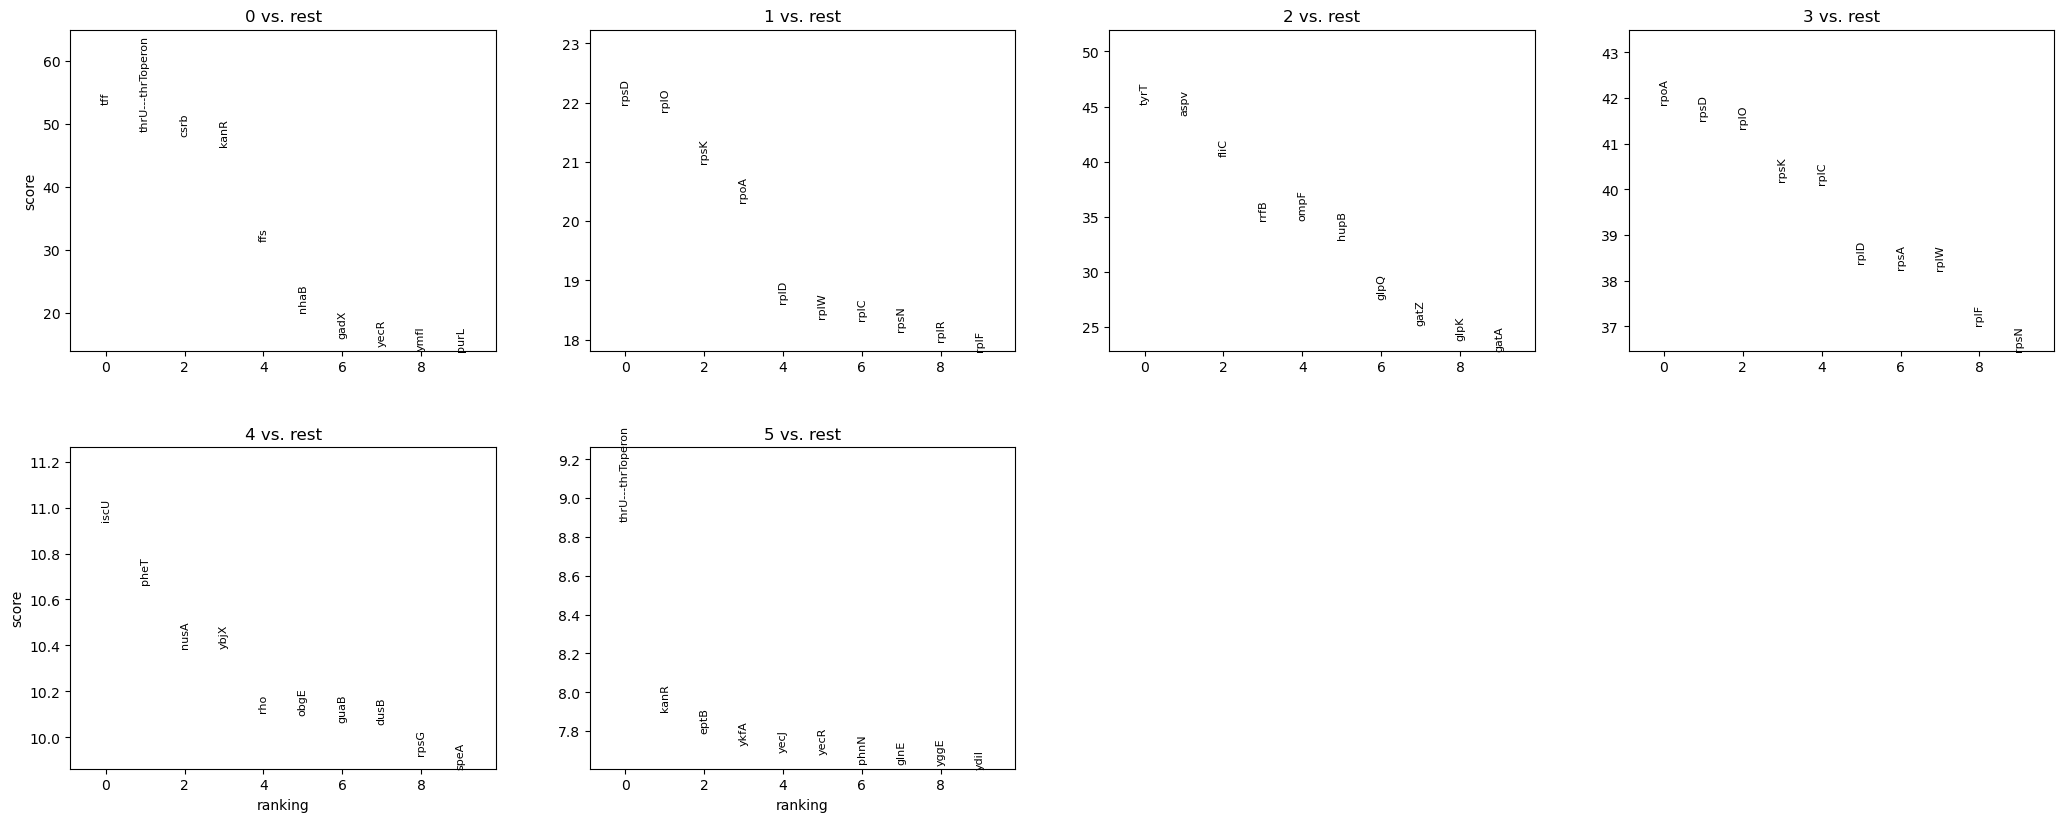

In [80]:
# analyze vapC datasets:
import scanpy as sc
import os
import numpy as np
# concatenated matrix
dir = os.path.join(os.path.dirname(os.getcwd()), 'data_for_umap')
# exp
file_name = 'EXP_biorep_t0A_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
exp = sc.read_csv(path)
# shx1
file_name = 'VapC_biorep_t2A_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
t2 = sc.read_csv(path)
# shx2
file_name = 'VapC_biorep_t5A_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
t5a = sc.read_csv(path)
# casp1
file_name = 'VapC_biorep_t5B_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
t5b = sc.read_csv(path)
# casp2
file_name = 'VapC_biorep_tONA_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
tON = sc.read_csv(path)

# Step 1: Load your data
adata = sc.concat(
    [exp,t2, t5a,t5b, tON],  # List of AnnData objects to concatenate
    join='inner',  # How to join the data (outer = union of genes, inner = intersection)
    fill_value=0,  # Fill missing values with this
    label='batch',               # New column name in .obs that stores which sample each cell came from
    keys=['exp','T2','T5A','T5B','TON'],  # Names for the batches
    index_unique='-'              # How to make cell names unique (Sample1-0, Sample1-1, etc.)
)  # Replace with your file path
# List of genes you want to remove
genes_to_remove = ['mCherry', 'tetR', 'LacI','GFP','ampR']  # Example genes
# Keep only genes not in the list
adata = adata[:, ~adata.var_names.isin(genes_to_remove)]
# Step 2: Basic preprocessing
#sc.pp.filter_cells(adata, min_genes=200)     # Optional: filter cells
sc.pp.filter_genes(adata, min_cells=3)        # Optional: filter genes
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize
sc.pp.log1p(adata)                            # Log-transform
sc.pp.highly_variable_genes(adata, n_top_genes=1000, subset=True)  # Keep top 2000 HVGs
adata.raw = adata  # Store the raw counts in a separate layer
# Step 3: PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute neighbors and run UMAP
sc.pp.neighbors(adata, n_neighbors=40, n_pcs=40)
sc.tl.umap(adata, min_dist=0.4, random_state=0)

# Step 5: Clustering
sc.tl.leiden(adata, resolution=.8)  # You can adjust resolution (higher = more clusters)

# Step 6: Plot UMAP
sc.pl.umap(adata, color=['leiden','batch'])
# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon', use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

# Optional: Save the results
#adata.write('scanpy_vapc.h5ad')


[]

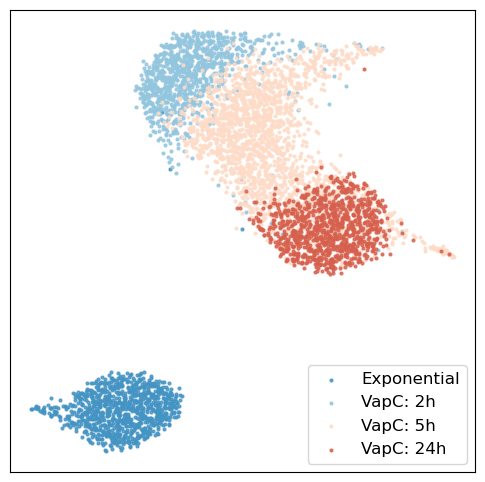

In [368]:
# load UMAP coordinates
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), 'scanpy', 'umap_coordinates_vapc.csv'), index_col=0, header=0)
fig,ax = plt.subplots(figsize=(6, 6))
# scatter plot
exp_data = data[data['batch'] == 'exp']
t2_data = data[data['batch'] == 'T2']
t5a_data = data[np.logical_or(data['batch'] == 'T5A', data['batch'] == 'T5B')]
dis_data = data[data['batch']=='TON']
colors = ['#4393c3','#92c5de','#fddbc7','#d6604d']
ax.scatter(exp_data.UMAP_1, exp_data.UMAP_2, color = colors[0], alpha=.8, s=4, label='Exponential')
ax.scatter(t2_data.UMAP_1, t2_data.UMAP_2, color = colors[1], alpha=.8, s=4, label='VapC: 2h')
ax.scatter(t5a_data.UMAP_1, t5a_data.UMAP_2, color = colors[2], alpha=.8, s=4, label='VapC: 5h')
ax.scatter(dis_data.UMAP_1, dis_data.UMAP_2, color = colors[3], alpha=.8, s=4, label='VapC: 24h')
ax.legend(fontsize=12, loc='lower right', )
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

In [15]:
import scanpy as sc
import pandas as pd
path = os.path.join(os.path.dirname(os.getcwd()), 'scanpy', 'umap_coordinates.csv')
output_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'scanpy_shx.h5ad')
# 2. Read the CSV that contains at least:
#    - a column of cell IDs matching adata.obs_names
#    - a column with the cluster labels you want to add
# Adjust index_col / names as appropriate.
df = pd.read_csv(path, index_col=0)
# e.g. if the CSV columns are ['cell_id','UMAP1','UMAP2','cluster'], 
# you could do:
# df = pd.read_csv("/mnt/data/umap_coordinates.csv").set_index("cell_id")

# 3. Verify alignment
shared = adata.obs_names.intersection(df.index)
if len(shared) < adata.n_obs:
    missing = list(adata.obs_names.difference(df.index))
    raise ValueError(f"{len(missing)} cells in adata not found in CSV index; first few: {missing[:5]}")

# 4. Add the cluster column (rename 'cluster' below to your CSV’s column name)
adata.obs["leiden"] = df.loc[adata.obs_names, "cluster"]
adata.obs["UMAP_X"] = df.loc[adata.obs_names, "UMAP_1"]
adata.obs["UMAP_Y"] = df.loc[adata.obs_names, "UMAP_2"]
# 5. (Optional) make it categorical and order levels
adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# 6. Save out if you like
adata.write_h5ad(output_path)

In [75]:
# write marker genes to excel
import pandas as pd
# 1. Load your AnnData
path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'scanpy_vapc.h5ad')
adata = sc.read_h5ad(path)  # ← replace with your path
#sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize
#sc.pp.log1p(adata)                            # Log-transform
#sc.pp.highly_variable_genes(adata, n_top_genes=3000,subset=True)  # Keep top 2000 HVGs
# 2. Choose the obs-column that holds your cluster labels
adata.raw = adata
cluster_key = "leiden"  # or "louvain", etc.
if cluster_key not in adata.obs:
    raise KeyError(f"Could not find '{cluster_key}' in adata.obs. Available: {list(adata.obs.columns)}")
# 3. Compute marker genes per cluster (you can switch method to 't-test', 'wilcoxon', etc.)
sc.tl.rank_genes_groups(adata, groupby=cluster_key, method="wilcoxon", layer='counts', use_raw=False)

# 4. Pull out the results
rg = adata.uns["rank_genes_groups"]
clusters = rg["names"].dtype.names  # tuple of cluster IDs/names

# 5. Write to Excel: one sheet per cluster
output_path = "marker_genes_per_cluster_vapc.xlsx"
with pd.ExcelWriter(output_path) as writer:
    for cl in clusters:
        genes = rg["names"][cl]
        scores = rg["scores"][cl]
        logfoldchanges = rg["logfoldchanges"][cl]
        pvals_adj = rg["pvals_adj"][cl]
        df = pd.DataFrame({
            "gene": genes,
            "score": scores,
            "log2_fold_change": logfoldchanges,
            "adjusted_pval": pvals_adj
        })
        # Sheet names must be <= 31 chars and unique
        sheet_name = str(cl)[:31]
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Done — marker genes written to '{output_path}'")

KeyError: 'counts'

In [14]:
# find common marker genes between two datasets
import os
import pandas as pd
import numpy as np
path_dir = os.path.join(os.path.dirname(os.getcwd()),'scanpy')
file1 = 'marker_genes_per_cluster_shx_scaled.xlsx'
file2 = 'marker_genes_per_cluster_vapc.xlsx'
# read excel
sheet1 = pd.read_excel(os.path.join(path_dir, file1), sheet_name='1')
sheet2 = pd.read_excel(os.path.join(path_dir, file2), sheet_name='1')

sheet1 = sheet1[np.logical_and(sheet1['score']>0,sheet1['adjusted_pval']<0.05)]
sheet2 = sheet2[np.logical_and(sheet2['score']>0,sheet2['adjusted_pval']<0.05)]
# find common genes
common_genes = set(sheet1['gene']).intersection(set(sheet2['gene']))
common_gene_scores = {}
max_score1 = sheet1['score'].max()
max_score2 = sheet2['score'].max()
for gene in common_genes:
    common_gene_scores[gene] = (sheet1[sheet1['gene'] == gene]['score'].values[0]/max_score1+sheet2[sheet2['gene'] == gene]['score'].values[0]/max_score2)/2
# sort by score
common_gene_scores = dict(sorted(common_gene_scores.items(), key=lambda item: item[1], reverse=True))


dict_keys(['yrbL', 'clpA', 'cfa', 'pgk', 'ygaT', 'clpB', 'glmS', 'uvrB', 'bfr', 'pnuC', 'hslO', 'sdaA', 'fdoG', 'acnA', 'ycfH', 'yjjK', 'lrp', 'tolC', 'ftsA', 'hslV', 'yiaF', 'pepN', 'lpp', 'mtlA', 'amyA', 'fadL', 'ligA', 'ygiC', 'ytfK', 'fadE', 'ybeZ', 'rsd', 'ydcL', 'raiA', 'fbaA', 'uspF', 'malT', 'artI', 'cls', 'dcyD', 'rraA', 'yadG', 'nadE', 'def', 'manZ', 'ycfD', 'acrB', 'ybeY', 'ycjG', 'nupG', 'tsr', 'yceG', 'exbD', 'manY', 'aroH', 'acs', 'cstA', 'tppB', 'nanA', 'ygdH', 'crp', 'yliB', 'aldA', 'accC', 'glnH', 'cyaA', 'moaA', 'serS', 'agp', 'exbB', 'lysS', 'surA', 'glcB', 'ysgA', 'ycbW', 'tpiA', 'ypeA', 'yibN', 'proS', 'ytjC', 'yhbS', 'yliA', 'lolB', 'cycA', 'cdd', 'sstT', 'lepA', 'secF', 'spr', 'lysP', 'glcC', 'kdsA', 'bcp', 'glgX', 'tas', 'dppA', 'tonB'])

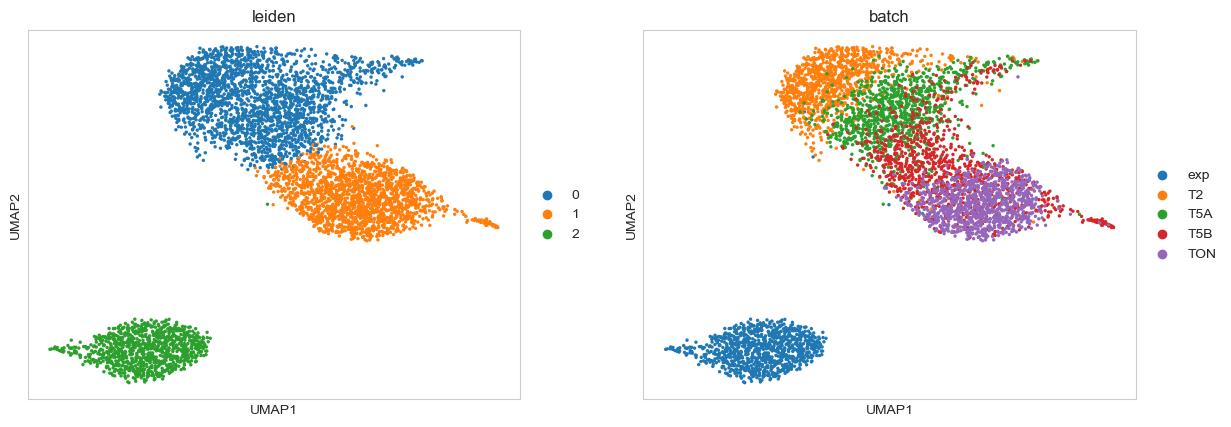

In [7]:
# load data
import scanpy as sc
import os
adata = sc.read_h5ad(os.path.join(os.path.dirname(os.getcwd()), 'data', 'scanpy_vapc.h5ad'))
sc.pl.umap(adata, color=['leiden','batch'])